# K-Means-Segmentierung des Abonnentenverhaltens mit PROC FASTCLUS


## Kurzfassung

Dieses Notebook segmentiert eine synthetische Basis von 100 Mobilfunk-Abonnenten mithilfe von `PROC FASTCLUS`, der k-Means-Clusterprozedur von Base SAS, in Verhaltenscluster. Sieben Nutzungsmerkmale werden mit `PROC STDIZE` auf Z-Werte standardisiert, damit Variablen mit hoher Größenordnung (Sprachminuten, SMS-Anzahl) die euklidische Distanz nicht dominieren; anschließend passt `PROC FASTCLUS` drei Cluster an. Die Prozedur berichtet die mittlere quadratische Abweichung innerhalb der Cluster, ein Gesamt-R-Quadrat und einen Pseudo-F-Wert, die quantifizieren, wie sauber die Segmentierung die Basis trennt (hier ein Gesamt-R-Quadrat von 0,575 und ein Pseudo-F von 65,75), und schreibt eine bewertete Tabelle mit einer `CLUSTER`-Kennzeichnung für jeden Abonnenten. Wir führen diese Kennzeichnungen mit den Daten im Originalmaßstab zusammen, profilieren die Personas und übergeben die Zuordnungen an die nachgelagerte Aktivierung.

## Datenquellen

| Datensatz | Beschreibung | Zeilen | Schlüsselvariablen |
| --------- | ------------ | -----: | ------------------- |
| `subscribers` | Synthetischer monatlicher Verhaltens-Schnappschuss für eine Mobilfunk-Abonnentenbasis, inline erzeugt mit `call streaminit` / `rand()`. Drei latente Verhaltenstypen (datenintensiv, sprachzentriert, geringe Nutzung) werden mit Rauschen vermischt. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominal), `region` (nominal) |

# K-Means-Segmentierung des Abonnentenverhaltens

**Branche:** Telekommunikation &nbsp;|&nbsp; **Prozedur:** `PROC FASTCLUS` (k-Means-Clustering in Base SAS)

Mobilfunkanbieter betreuen Abonnenten, deren monatliches Verhalten -- Datenappetit, Sprachgewohnheiten, Ausgaben und Support-Reibung -- in eine Handvoll wiedererkennbarer Muster zerfällt. Das Erkennen dieser Muster erlaubt es dem Unternehmen, Rückgewinnungsmaßnahmen zuzuschneiden, die passenden Pakete hochzuverkaufen und ähnliche Zielgruppen zu gewinnen. Dieses Notebook baut eine Verhaltenssegmentierung von Anfang bis Ende auf: Es erzeugt einen realistischen Abonnenten-Schnappschuss, standardisiert die Merkmale, lässt `PROC FASTCLUS` die Cluster anpassen, bewertet jeden Abonnenten und profiliert die Segmente zu handlungsfähigen Personas. `PROC FASTCLUS` ist genau für diese disjunkte k-Means-Aufgabe konzipiert und skaliert auf sehr große Basen, indem es die Daten durchläuft, statt eine vollständige Distanzmatrix aufzubauen.

## 1. Eine synthetische Abonnentenbasis erzeugen

Wir simulieren 100 Abonnenten, gezogen aus drei latenten Verhaltensarchetypen -- **datenintensive Streamer**, **sprachzentrierte Traditionalisten** und **Kunden mit geringer Nutzung** -- und mischen anschließend Rauschen bei, sodass die Grenzen unscharf sind (wie in der Realität). Jeder Abonnent trägt außerdem zwei kategoriale Attribute, `data_plan` und `region`, die wir später zum *Profilieren* der Segmente verwenden. Der Seed macht die Daten reproduzierbar.

In [1]:
/* -----------------------------------------------------------
   Synthetic mobile subscriber snapshot (100 rows).
   Three latent behavior archetypes + noise, plus two
   categorical attributes for segment profiling.
   ----------------------------------------------------------- */
DATEN subscribers;
    AUFRUFEN streaminit(20260531);

    LÄNGE data_plan $12 region $12;

    AUSFÜHRUNG subscriber_id = 100001 BIS 100100;

        /* latent archetype: 1=heavy data, 2=voice, 3=low usage */
        u = rand('uniform');
        WENN      u < 0.38 DANN archetype = 1;
        SONST WENN u < 0.70 DANN archetype = 2;
        SONST                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        WENN archetype = 1 DANN AUSFÜHRUNG;             /* heavy-data streamer */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        ENDE;
        SONST WENN archetype = 2 DANN AUSFÜHRUNG;        /* voice-centric */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        ENDE;
        SONST AUSFÜHRUNG;                              /* low usage */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        ENDE;

        WENN planpick = 1 DANN data_plan = 'Prepaid';
        SONST WENN planpick = 2 DANN data_plan = 'VertragM';
        SONST data_plan = 'Unbegrenzt';

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        WENN      region_pick = 1 DANN region = 'Nord';
        SONST WENN region_pick = 2 DANN region = 'Süd';
        SONST WENN region_pick = 3 DANN region = 'Ost';
        SONST                          region = 'West';

        /* round to tidy reporting precision */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        AUSGABE;
    ENDE;

    BEHALTEN subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
AUSFÜHREN;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Die Merkmalsverteilungen untersuchen

Vor dem Clustering betrachten wir Skala und Streuung jedes Verhaltensmerkmals. Die stark unterschiedlichen Einheiten -- Gigabyte, Minuten, Dollar, Zählwerte -- sind genau der Grund, warum wir die intervallskalierten Eingaben vor dem Clustering standardisieren; sonst würden Variablen mit hoher Größenordnung wie `voice_minutes` die euklidische Distanz dominieren, die `PROC FASTCLUS` minimiert.

                                                  The MEANS Procedure

 Variable         Label                                 N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Vertragsdauer (Monate)              100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Monatliches Datenvolumen (GB)       100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Sprachminuten                       100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        SMS-Anzahl                          100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


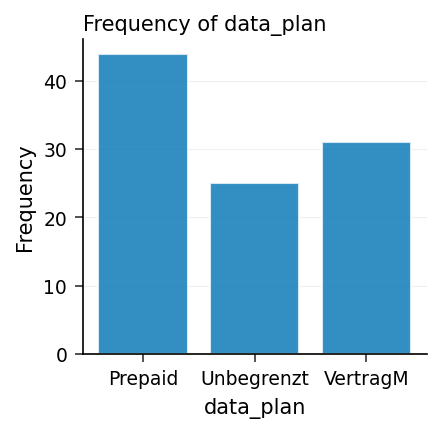

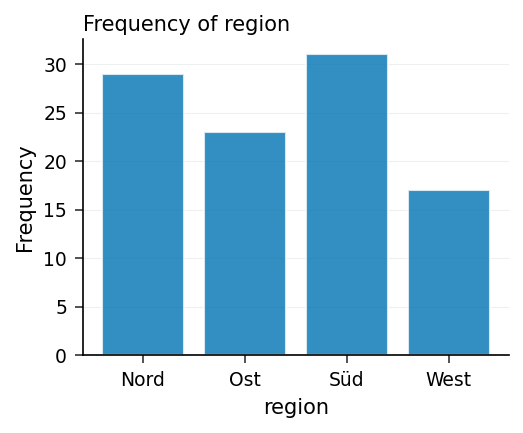

In [2]:
/* Summary statistics for the clustering inputs */
PROZEDUR MITTELWERTE DATEN=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    BEZEICHNUNG tenure_months   = 'Vertragsdauer (Monate)'
          monthly_data_gb = 'Monatliches Datenvolumen (GB)'
          voice_minutes   = 'Sprachminuten'
          sms_count       = 'SMS-Anzahl'
          intl_minutes    = 'Auslandsminuten'
          arpu            = 'ARPU ($)'
          support_calls   = 'Support-Anrufe';
AUSFÜHREN;

/* Frequency of the two categorical inputs */
PROZEDUR HÄUFIGKEITEN DATEN=subscribers;
    TABLES data_plan region / nocum;
    BEZEICHNUNG data_plan = 'Tarif'
          region    = 'Region';
AUSFÜHREN;

## 3. Die Merkmale auf Z-Werte standardisieren

`PROC FASTCLUS` minimiert die euklidische Distanz, sodass eine in Hunderten von Minuten gemessene Variable eine einstellige Gigabyte-Variable überschwemmen würde. `PROC STDIZE` mit `METHOD=STD` skaliert jedes intervallskalierte Merkmal auf Mittelwert 0 und Standardabweichung 1 um und gibt so jedem Verhalten gleiches Gewicht in der Distanz. Die kategorialen Spalten und der Identifikator laufen unverändert durch, damit wir die Cluster anschließend auf ihrer Originalskala profilieren können.

In [3]:
/* z-score the interval features; ids and categoricals pass through */
PROZEDUR stdize DATEN=subscribers out=subs_std METHOD=std;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    BEZEICHNUNG tenure_months   = 'Vertragsdauer (Monate)'
          monthly_data_gb = 'Monatliches Datenvolumen (GB)'
          voice_minutes   = 'Sprachminuten'
          sms_count       = 'SMS-Anzahl'
          intl_minutes    = 'Auslandsminuten'
          arpu            = 'ARPU ($)'
          support_calls   = 'Support-Anrufe';
AUSFÜHREN;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Die k-Means-Segmentierung anpassen

Wir passen mit `PROC FASTCLUS` drei Segmente an. `MAXCLUSTERS=3` legt *k* fest; `MAXITER=20` lässt die Clusterzentren bis zur Konvergenz iterieren. Die Prozedur berichtet eine **Cluster-Zusammenfassung** (Größe und mittlere quadratische Abweichung innerhalb des Clusters je Cluster), **Statistiken für Variablen** (das R-Quadrat, das jedes Merkmal beiträgt), ein **Gesamt-R-Quadrat** und einen **Pseudo-F-Wert**, die messen, wie sauber die drei Cluster die Basis trennen, sowie **Cluster-Mittelwerte** auf der standardisierten Skala. `OUT=scored` schreibt die Eingabezeilen mit einer `CLUSTER`-Kennzeichnung und der `DISTANCE` jedes Abonnenten zu seinem Cluster-Seed zurück.

In [4]:
/* k-means fit on the standardized features: 3 segments. */
PROZEDUR FASTCLUS DATEN=subs_std maxclusters=3 MAXITER=20 out=scored;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    BEZEICHNUNG tenure_months   = 'Vertragsdauer (Monate)'
          monthly_data_gb = 'Monatliches Datenvolumen (GB)'
          voice_minutes   = 'Sprachminuten'
          sms_count       = 'SMS-Anzahl'
          intl_minutes    = 'Auslandsminuten'
          arpu            = 'ARPU ($)'
          support_calls   = 'Support-Anrufe';
AUSFÜHREN;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Segmentkennzeichnungen an die Originaldaten anhängen

Die bewertete Tabelle enthält die standardisierten Merkmale; für die Profilierung wollen wir die Cluster in echten Gigabyte, Minuten und Dollar beschrieben sehen. Wir führen die `CLUSTER`-Kennzeichnung anhand von `subscriber_id` mit der ursprünglichen `subscribers`-Tabelle zusammen und stellen dann die erste Frage, die das Marketing immer stellt: *Wie groß ist jedes Segment?*

                                                   The FREQ Procedure

Segment    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


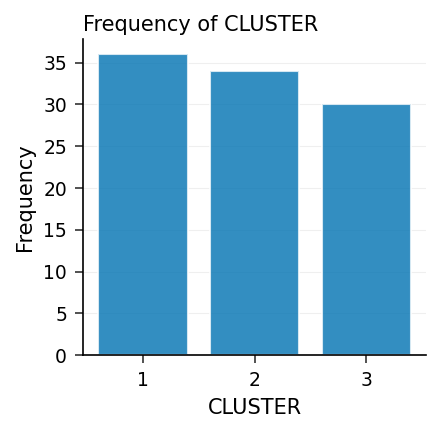

In [5]:
/* carry the cluster label back to the original-scale data */
PROZEDUR SORTIEREN DATEN=scored(BEHALTEN=subscriber_id CLUSTER distance) out=clus_assign;
    NACH subscriber_id;
AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=subscribers out=subs_sorted;
    NACH subscriber_id;
AUSFÜHREN;
DATEN profile;
    ZUSAMMENFÜHREN subs_sorted clus_assign;
    NACH subscriber_id;
AUSFÜHREN;

/* How many subscribers landed in each segment? */
PROZEDUR HÄUFIGKEITEN DATEN=profile;
    TABLES CLUSTER / nocum;
    BEZEICHNUNG CLUSTER = 'Segment';
AUSFÜHREN;

## 6. Die Segmente profilieren

Cluster-IDs sind bedeutungslos, solange wir das *Verhalten* innerhalb jedes einzelnen nicht beschreiben. Die Mittelung der ursprünglichen (nicht standardisierten) Merkmale nach `CLUSTER` offenbart die Persona hinter jedem Segment -- wer streamt, wer telefoniert, wer das Netz kaum nutzt -- und die kategoriale Verteilung zeigt, welche Tarife und Regionen sich in welchem Segment konzentrieren.

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months Vertragsdauer (Monate)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                           Analysis Variable : monthly_data_gb Monatliches Datenvolumen (GB)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                    Analysis Variable : voice_minutes Sprachminuten

        Segment           N Obs           Mean
        --------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


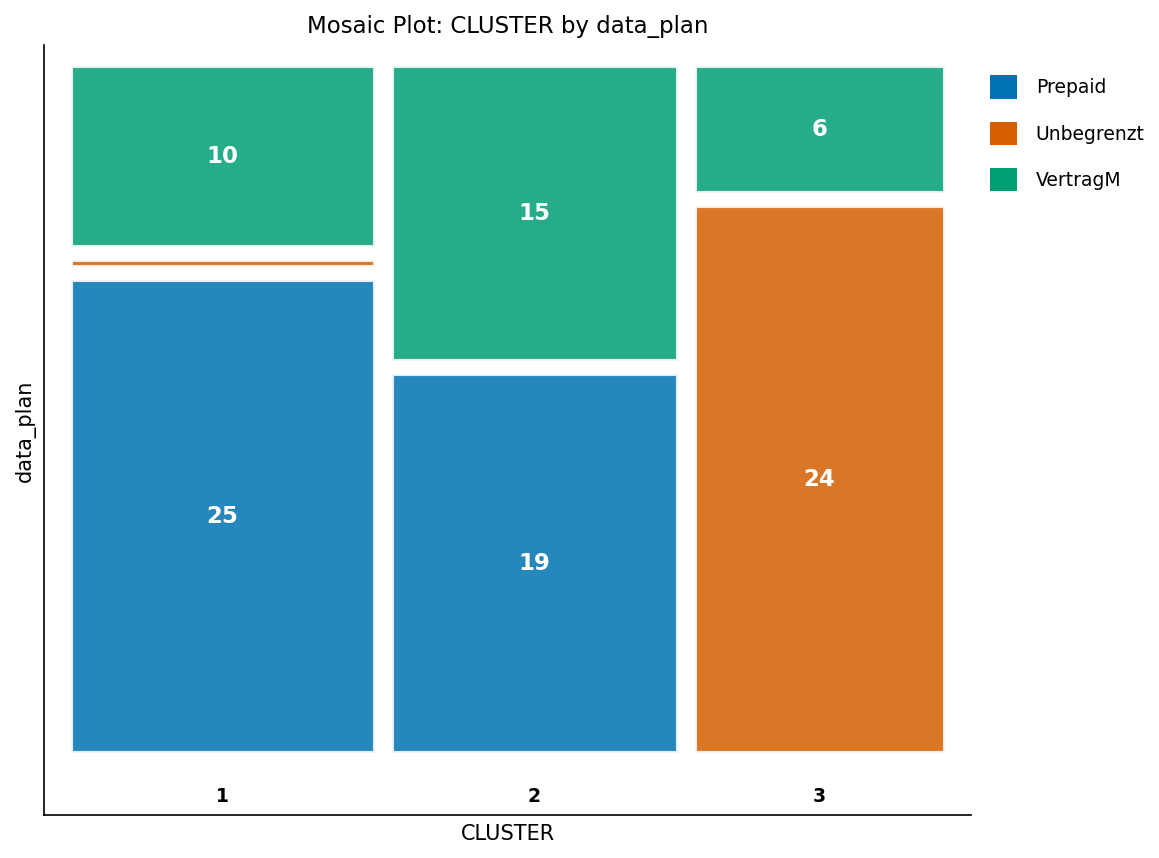

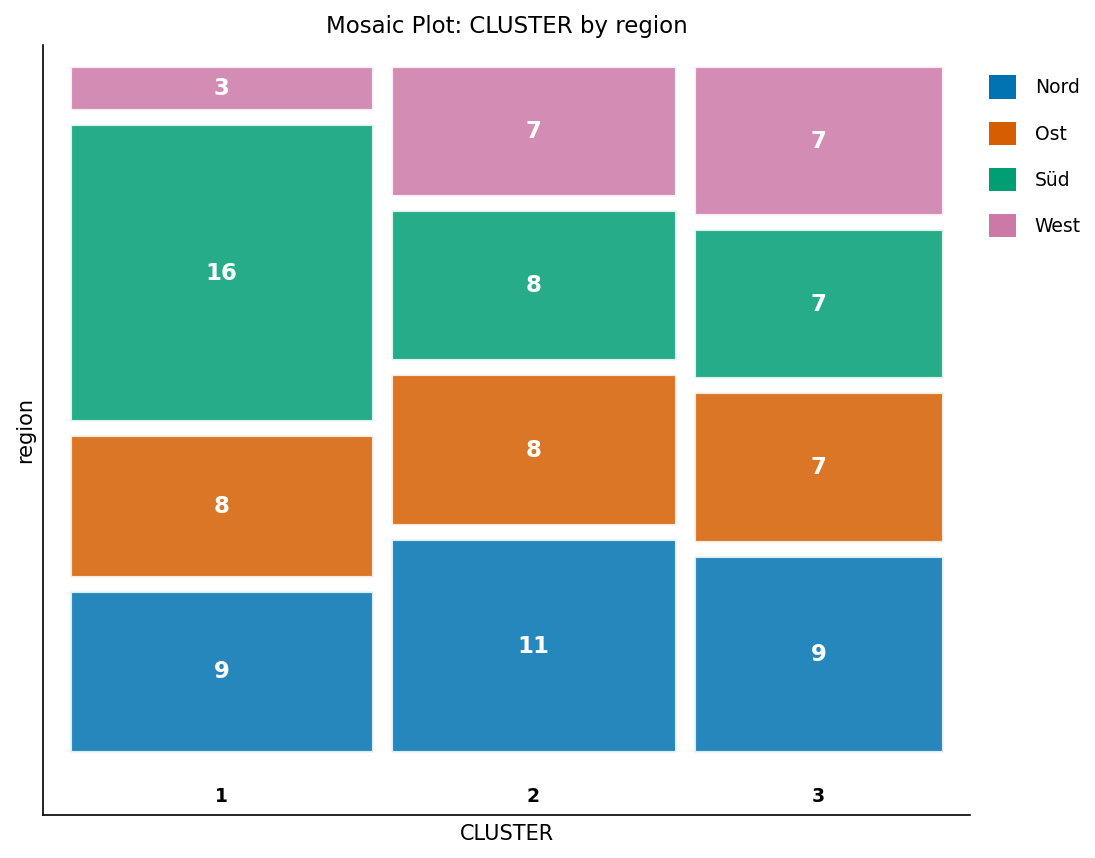

In [6]:
/* Behavioral profile: mean of each feature by segment */
PROZEDUR MITTELWERTE DATEN=profile n mean maxdec=1;
    KLASSE CLUSTER;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    BEZEICHNUNG CLUSTER         = 'Segment'
          tenure_months   = 'Vertragsdauer (Monate)'
          monthly_data_gb = 'Monatliches Datenvolumen (GB)'
          voice_minutes   = 'Sprachminuten'
          sms_count       = 'SMS-Anzahl'
          intl_minutes    = 'Auslandsminuten'
          arpu            = 'ARPU ($)'
          support_calls   = 'Support-Anrufe';
AUSFÜHREN;

/* Categorical mix within each segment */
PROZEDUR HÄUFIGKEITEN DATEN=profile;
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
    BEZEICHNUNG CLUSTER   = 'Segment'
          data_plan = 'Tarif'
          region    = 'Region';
AUSFÜHREN;

## 7. Die Segmente visualisieren

Ein Bild macht die Segmentierung greifbar. Wir stellen den Datenappetit gegen die Sprachnutzung dar, eingefärbt nach Segment, und fügen einen Boxplot des ARPU je Segment hinzu, damit die Umsatzgeschichte auf einen Blick klar wird.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


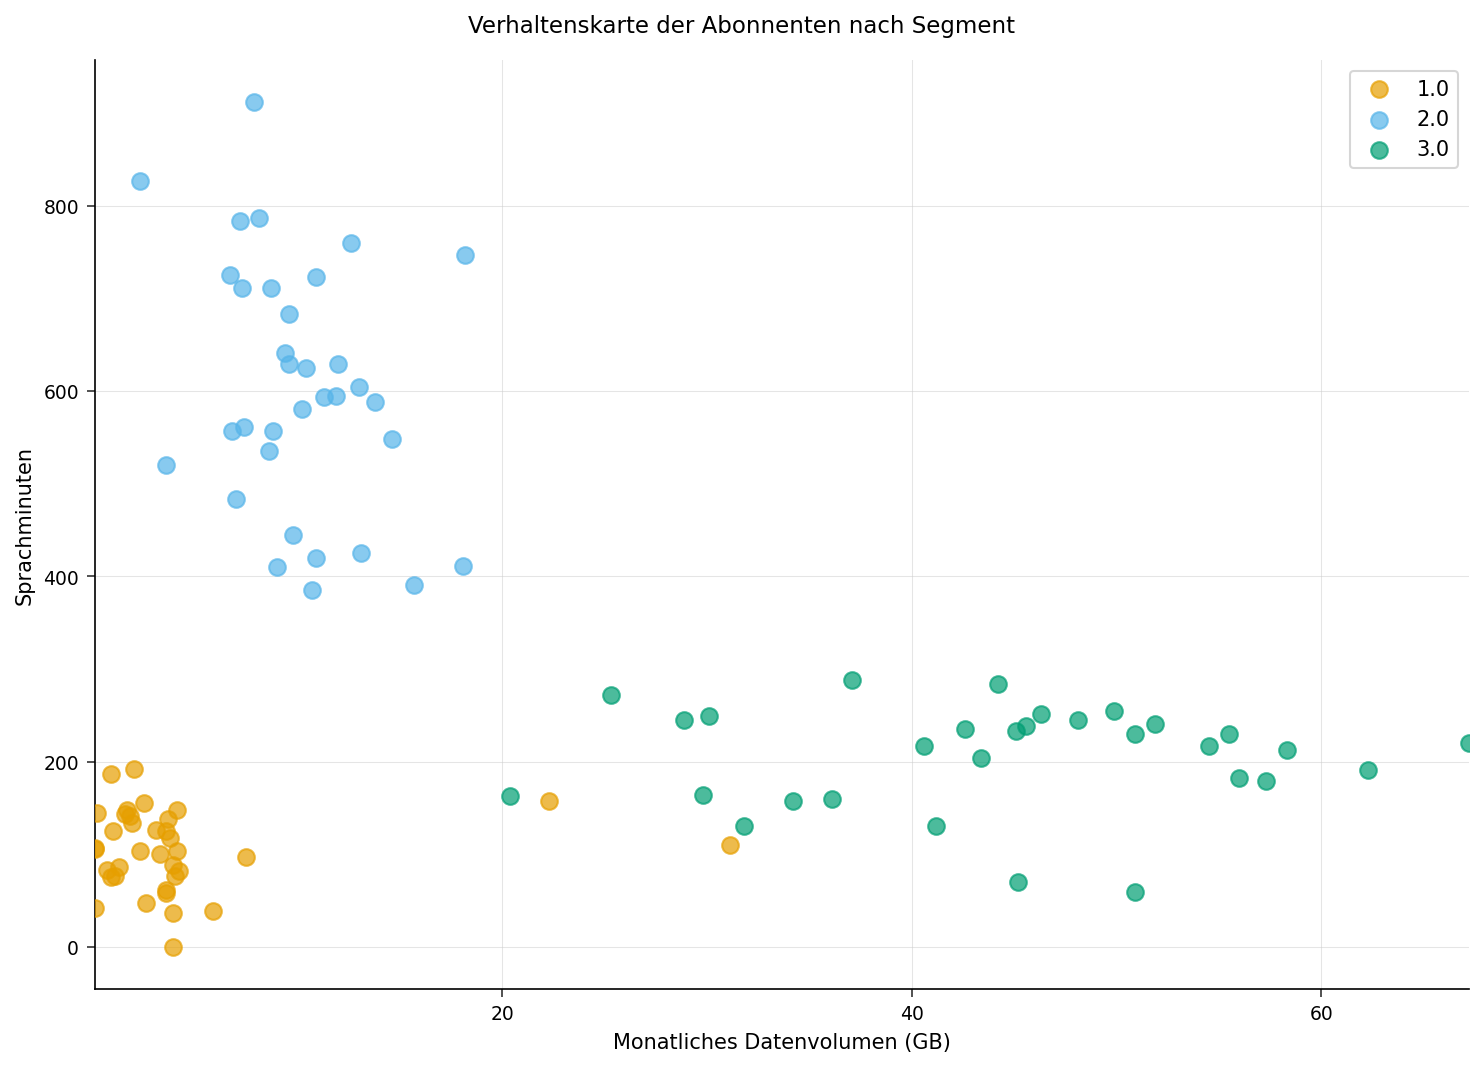

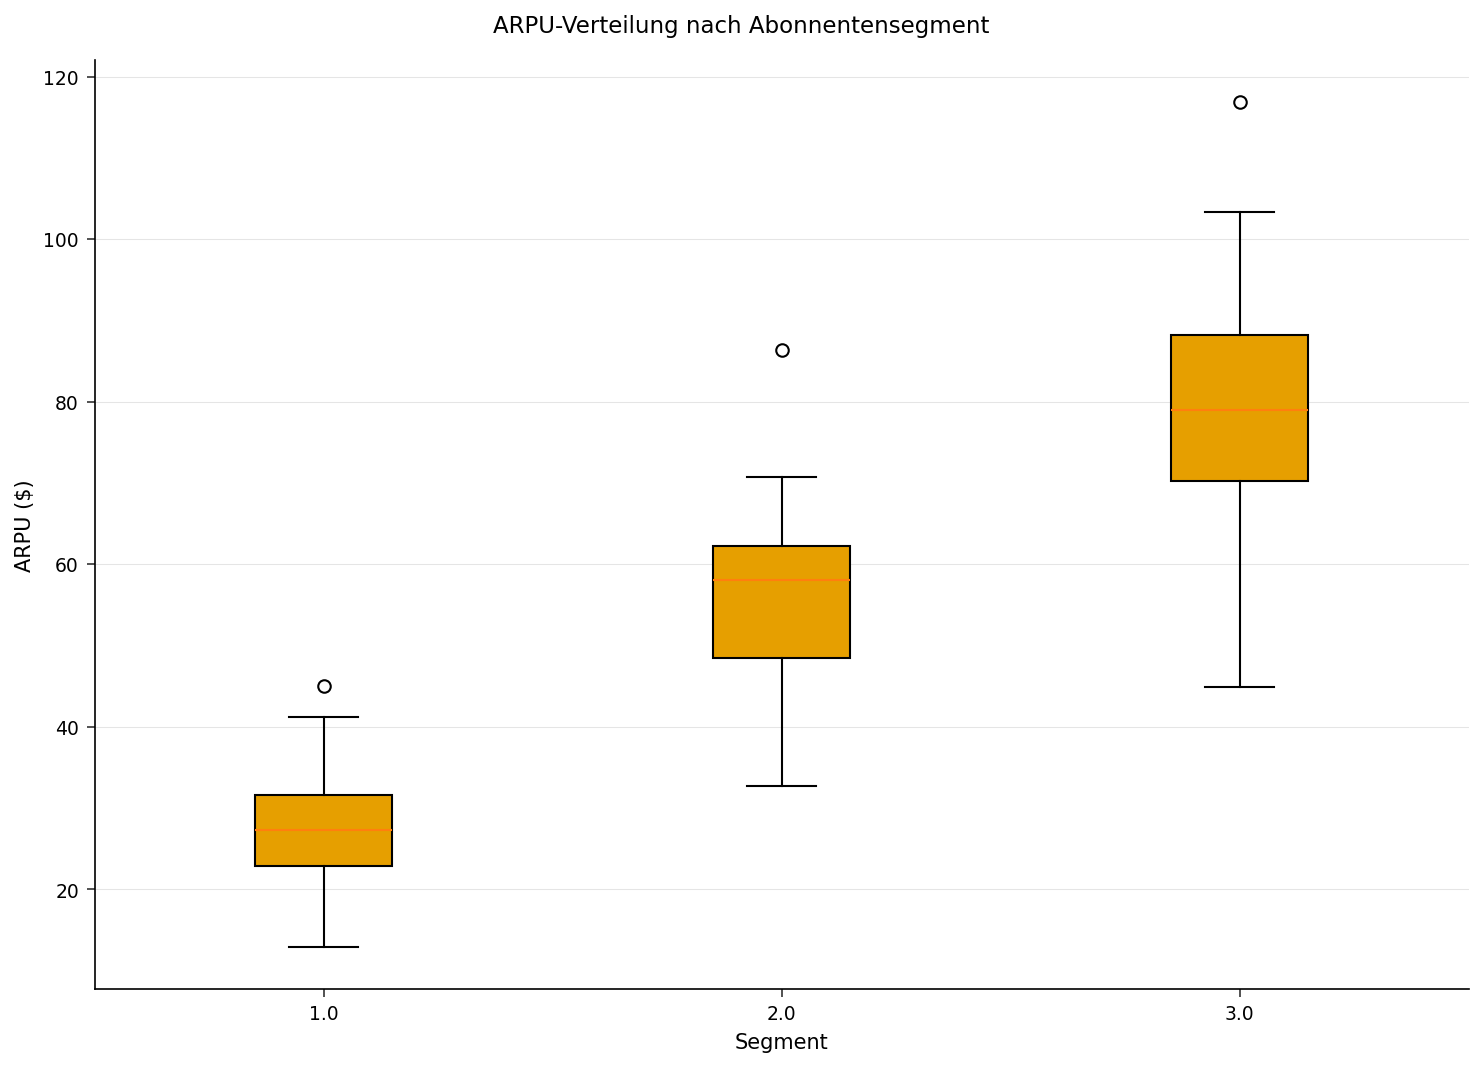

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Behavioral map: data vs. voice, colored by segment */
PROZEDUR SGPLOT DATEN=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS BEZEICHNUNG='Monatliches Datenvolumen (GB)' grid;
    YAXIS BEZEICHNUNG='Sprachminuten'     grid;
    TITEL 'Verhaltenskarte der Abonnenten nach Segment';
AUSFÜHREN;

/* Revenue distribution per segment */
PROZEDUR SGPLOT DATEN=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS BEZEICHNUNG='Segment';
    YAXIS BEZEICHNUNG='ARPU ($)' grid;
    TITEL 'ARPU-Verteilung nach Abonnentensegment';
AUSFÜHREN;

## 8. Die bewerteten Segmente exportieren

Zum Schluss übergeben wir die Zuordnungen an nachgelagerte CRM- und Kampagnensysteme. Wir behalten den Identifikator, die Clusterkennzeichnung und die wichtigsten Verhaltensfelder.

In [8]:
/* Persist the segment assignments for activation */
DATEN subscriber_segments;
    FESTLEGEN profile;
    BEHALTEN subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=subscriber_segments(obs=10) noobs;
    BEZEICHNUNG subscriber_id   = 'Abonnenten-ID'
          CLUSTER         = 'Segment'
          tenure_months   = 'Vertragsdauer (Monate)'
          monthly_data_gb = 'Monatliches Datenvolumen (GB)'
          voice_minutes   = 'Sprachminuten'
          arpu            = 'ARPU ($)'
          data_plan       = 'Tarif'
          region          = 'Region';
    TITEL 'Beispiel bewerteter Abonnentensegmente';
AUSFÜHREN;

                                         Beispiel bewerteter Abonnentensegmente                                         

Abonnenten-ID  Segment  Vertragsdauer (Monate)  Monatliches Datenvolumen (GB)  Sprachminuten  ARPU ($)       Tarif  Region
       100001        1                      30                            2.3            104        28  Prepaid     Süd
       100002        2                       8                           10.2            581     57.78  Prepaid     West
       100003        2                       8                           10.7            385     55.66  VertragM    Nord
       100004        2                      68                            7.4            561     70.68  Prepaid     Nord
       100005        3                      18                           45.6            239     63.85  Unbegrenzt  Nord
       100006        3                      10                           30.1            249     88.33  Unbegrenzt  Ost
       100007        1         


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Die Ergebnisse interpretieren

`PROC FASTCLUS` hat drei saubere, gut getrennte Segmente ermittelt. Die Anpassung ist solide: Das **Gesamt-R-Quadrat beträgt 0,575** und der **Pseudo-F-Wert 65,75**, was bedeutet, dass die drei Cluster etwa 58 % der Gesamtvariation in den standardisierten Merkmalen erklären. Die Trennung wird fast ausschließlich von den Verhaltenssignalen getragen, auf die es ankommt -- `voice_minutes` (R-Quadrat 0,858), `monthly_data_gb` (0,844) und `arpu` (0,771) tragen die Segmentierung, während `tenure_months` (0,000) und `support_calls` (0,193) fast nichts beitragen, was bestätigt, dass *wie* ein Abonnent das Netz nutzt -- nicht wie lange er schon Kunde ist -- die Personas definiert.

Die drei Segmente lassen sich direkt auf marketingfähige Personas abbilden, hier auf der ursprünglichen (nicht standardisierten) Skala profiliert:

| Segment | n (Anteil) | Charakteristisches Verhalten | Tarifmix | Persona | Empfohlene Maßnahme |
| :-----: | :--------: | ----------------------------- | -------- | ------- | -------------------- |
| **3** | 30 (30 %) | Höchster Datenverbrauch: **44,4 GB/Monat**, höchste Ausgaben **79,1 $ ARPU**, moderate Sprachnutzung (205 Min.) | 24/30 **Unbegrenzt** | **Datenintensive Streamer** | Schützen und hochverkaufen: schnellere Tarifstufen, Content-Pakete, Geräte-Upgrades |
| **2** | 34 (34 %) | Höchste Sprachnutzung **603 Min./Monat**, **214 SMS**, **106 Auslandsminuten**, mittlere Ausgaben **55,9 $ ARPU** | Prepaid + VertragM, **kein Unbegrenzt** | **Sprachzentrierte Traditionalisten** | Auslands-Zusatzoptionen, Familien-/Sprachpakete, Treueprämien |
| **1** | 36 (36 %) | Geringste Nutzung: **4,0 GB**, 104 Sprachminuten, niedrigste Ausgaben **28,0 $ ARPU** | 25/36 **Prepaid** | **Leicht-/Geringnutzer** | Tarife rechtgrößen, Autopay-Anreize, günstige Daten-Einstiegstarife zur Nutzungssteigerung |

Der Tarifmix bestätigt die Verhaltenslesart: Das datenintensive Segment liegt überwiegend auf **Unbegrenzt**-Tarifen (24 von 30), das sprachzentrierte Segment hält **keine** Unbegrenzt-Abonnenten, und das Geringnutzer-Segment ist überwiegend **Prepaid** (25 von 36). Die Region hingegen ist gleichmäßig über alle drei Segmente verteilt -- Geografie ist hier kein Verhaltenstreiber, was selbst ein nützlicher Befund für das Kampagnen-Targeting ist.

**Warum `PROC FASTCLUS` zu diesem Problem passt.** Die Prozedur führt disjunktes k-Means durch, indem sie die Daten durchläuft, statt eine vollständige Distanzmatrix zu materialisieren, sodass dasselbe Programm, das diese 100 Abonnenten segmentiert hat, auf sehr große Basen skaliert. Die Standardisierung mit `PROC STDIZE` entfernte zuerst die Skalenverzerrung zwischen Gigabyte, Minuten und Dollar, sodass jedes Verhalten gleich stark zur euklidischen Distanz beitrug; die R-Quadrat-Diagnosen zeigten dann, *welche* Merkmale die Trennung tatsächlich antrieben. Die bewertete Ausgabe -- eine `CLUSTER`-Kennzeichnung für jeden Abonnenten -- fließt direkt in Aktivierungspipelines ein und schließt den Kreis von rohem Verhalten zu gezieltem Angebot.

---

<div style="font-size:11px;color:#9e9e9e">Dieses Notebook dient ausschließlich Demonstrationszwecken. Die Daten sind synthetisch, und die Erkenntnisse stellen keine Geschäftsberatung dar.</div>